In [94]:
import matplotlib.pyplot as plt
import math
from skimage.transform import rotate
from skimage.transform import EuclideanTransform
from skimage.transform import SimilarityTransform
from skimage.transform import matrix_transform
from skimage.transform import warp
from skimage.transform import swirl
from skimage import io, color

from skimage import io, color
from skimage.morphology import binary_closing, binary_opening
from skimage.morphology import disk
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from skimage.color import label2rgb
import pydicom as dicom
from scipy.stats import norm
from scipy.spatial import distance

from skimage import color
from skimage.util import img_as_ubyte
from skimage.util import img_as_float
from skimage.filters import prewitt
from skimage.filters import threshold_otsu
from skimage.filters import median
import time
import cv2
import numpy as np
from scipy.ndimage import correlate
from skimage import io


import skimage
from skimage.util import img_as_float, img_as_ubyte
import cv2
from skimage import color, io
from matplotlib import pyplot as plt
import numpy as np
from skimage.filters import threshold_otsu
from skimage.color import rgb2hsv

from skimage import io, color, morphology
from skimage.util import img_as_float, img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb
import cv2
from utils import plot_comparison
from skimage.morphology import erosion, dilation,opening,closing,disk
from skimage.morphology import disk

/tmp/ipykernel_484168/3537151950.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img)


Number of connected moving objects: 36
Average Blue: 66.55
Average Blue: 60.36
Average Blue: 48.87
Average Blue: 44.24
Average Blue: 58.21
Average Blue: 70.10
Average Blue: 39.19
Average Blue: 103.68
Average Blue: 122.70
Average Blue: 130.26
Average Blue: 109.25
Average Blue: 60.71
Average Blue: 37.38
Average Blue: 45.87
Average Blue: 48.37
Average Blue: 126.73
Average Blue: 43.20
Average Blue: 48.79
Average Blue: 29.27
Average Blue: 49.27
Average Blue: 48.15
Average Blue: 53.61
Average Blue: 35.78
Average Blue: 126.71
Average Blue: 55.13
Average Blue: 125.46
Average Blue: 52.98
Average Blue: 33.38
Average Blue: 58.66
Average Blue: 43.61
Average Blue: 76.96
Average Blue: 65.53
Average Blue: 63.19
Average Blue: 41.83
Average Blue: 98.91
Average Blue: 66.04
Mean B values for all BLOBS: [ 66.5500619   60.36016193  48.87395358  44.24294986  58.2056554
  70.10276869  39.19351655 103.68447335 122.70279462 130.25604003
 109.25111919  60.71184061  37.37880415  45.87288946  48.36801177
 126.731

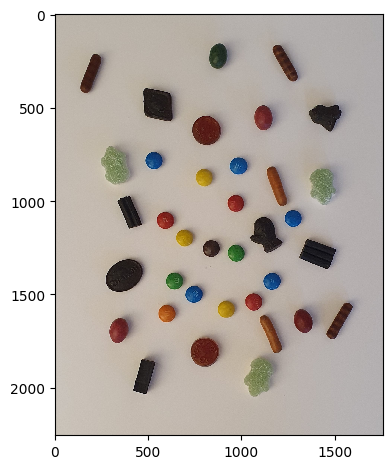

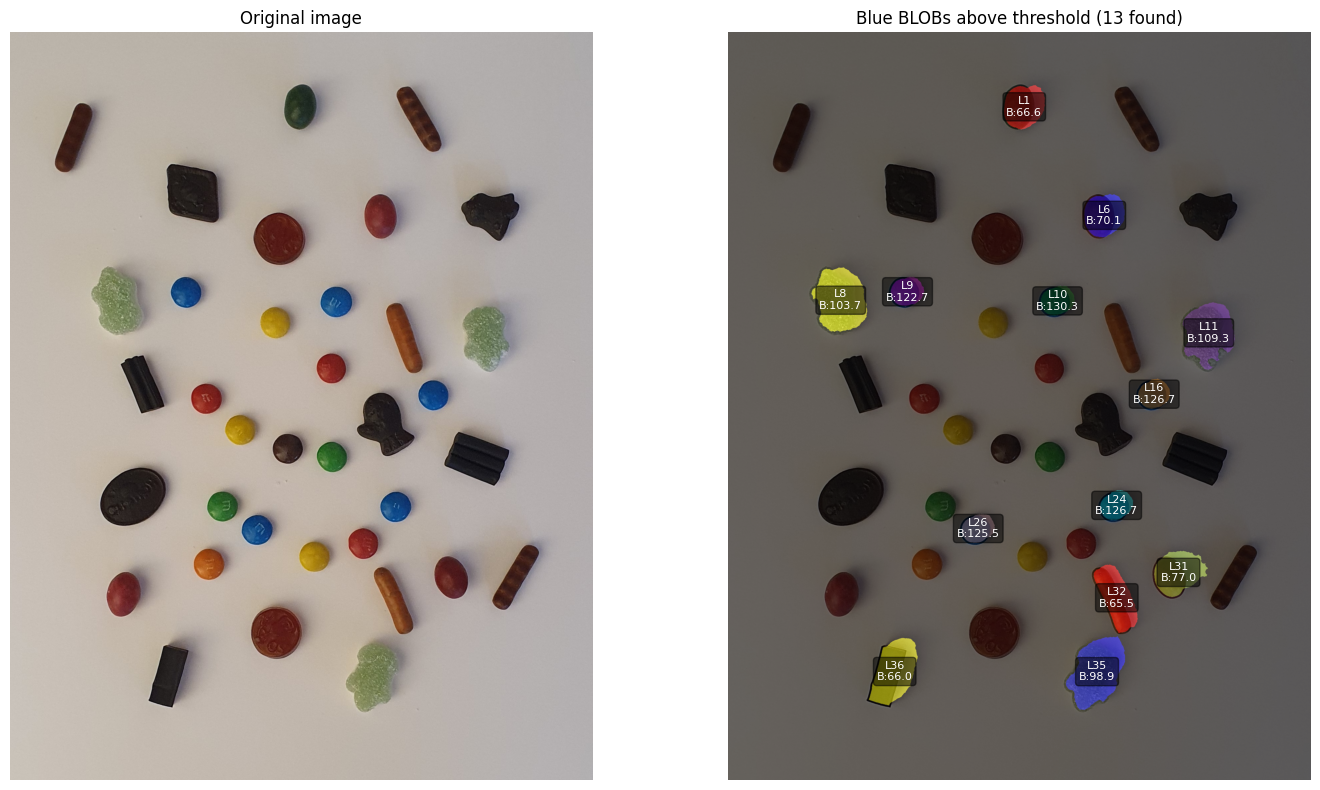

In [ ]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"

path = path + "candy/"

img = io.imread(path + "candy.jpg")

io.imshow(img)

img_gray = color.rgb2gray(img)

T = 0.6 


bin_img = img_gray < T


close_edit = closing(bin_img, disk(3))

erosion_edit = erosion(close_edit, disk(6))

label_img = measure.label(erosion_edit)
n_labels = label_img.max()
print(f"Number of connected moving objects: {n_labels}")


im_blob = label2rgb(label_img)
average_b = []
region_props = measure.regionprops(label_img)
area = np.array([prop.area for prop in region_props])
valid_bT = []
feature_matrix = []
for prop in region_props:
    # centroid returns (row, col) — matplotlib needs (x=col, y=row)
    blob_mask = label_img == prop.label
    pixels_in_blob = img[blob_mask]
    
    mean_R = pixels_in_blob[:,0].mean()
    mean_G = pixels_in_blob[:,1].mean()
    mean_B = pixels_in_blob[:,2].mean()

    # Geometric features (6)
    area        = prop.area
    perimeter   = prop.perimeter
    eccentricity = prop.eccentricity
    solidity    = prop.solidity
    extent      = prop.extent
    circularity = (4 * np.pi * prop.area) / (prop.perimeter ** 2)

    feature_matrix.append([mean_R, mean_G, mean_B, 
                           area, perimeter, eccentricity, 
                           solidity, extent, circularity])

    average_b.append(mean_B)
    print(f"Average Blue: {mean_B:.2f}")
    if mean_B >= 65:
        valid_bT.append(prop)
mean_b_values = np.array(average_b)
print(f"Mean B values for all BLOBS: {mean_b_values}")

threshold_b = np.quantile(mean_b_values, 0.65)
print(f"0.75 quantile threshold: {threshold_b}")



# ── Build a clean label image with only the valid blue BLOBs ─────────────────
clean_label = np.zeros_like(label_img)
for prop in valid_bT:
    clean_label[label_img == prop.label] = prop.label

# ── Visualize on the original image ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(img)
axes[0].set_title('Original image')

axes[1].imshow(img)  # show original as background
overlay = label2rgb(clean_label, bg_label=0)
axes[1].imshow(overlay, alpha=0.5)  # semi-transparent overlay
# Annotate each valid BLOB
for prop in valid_bT:
    cy, cx = prop.centroid
    axes[1].text(cx, cy,
                 f"L{prop.label}\nB:{img[label_img == prop.label][:, 2].mean():.1f}",
                 color='white', fontsize=8, ha='center', va='center',
                 bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

axes[1].set_title(f'Blue BLOBs above threshold ({len(valid_bT)} found)')
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()



#PCA

X = np.array(feature_matrix)



